In [22]:
#Generate Dataset
import numpy as np
import pandas as pd
np.random.seed(42)
n = 1000
data = pd.DataFrame({
    "candidate_skill": np.random.randint(1, 11, n),
    "candidate_experience": np.random.randint(0, 6, n),
    "candidate_work_style": np.random.randint(0, 2, n),
    "candidate_communication": np.random.randint(1, 11, n),

    "team_avg_skill": np.random.randint(1, 11, n),
    "team_experience": np.random.randint(0, 6, n),
    "team_work_style": np.random.randint(0, 2, n),
    "team_communication": np.random.randint(1, 11, n),
})

# Feature Engineering

data["skill_gap"] = abs(data["candidate_skill"] - data["team_avg_skill"])
data["experience_gap"] = abs(data["candidate_experience"] - data["team_experience"])
data["work_style_match"] = (data["candidate_work_style"] == data["team_work_style"]).astype(int)
data["communication_gap"] = abs(data["candidate_communication"] - data["team_communication"])

# Add Noise 

score = (
    0.4 * (data["skill_gap"] <= 3).astype(int) +
    0.3 * (data["experience_gap"] <= 2).astype(int) +
    0.2 * (data["work_style_match"] == 1).astype(int) +
    0.1 * (data["communication_gap"] <= 3).astype(int)
)

noise = np.random.normal(0, 0.1, len(data))

data["compatible"] = ((score + noise) > 0.5).astype(int)
data["candidate_skill"] += np.random.normal(0, 0.5, len(data))
data["team_avg_skill"] += np.random.normal(0, 0.5, len(data))

# Save dataset
data.to_csv("dataset_large.csv", index=False)


In [23]:
print("\nDataset Shape:", data.shape)
print("\nStatistical Summary:")
print(data.describe())
data.head()
print(data["compatible"].value_counts())


Dataset Shape: (1000, 13)

Statistical Summary:
       candidate_skill  candidate_experience  candidate_work_style  \
count      1000.000000           1000.000000           1000.000000   
mean          5.429929              2.464000              0.519000   
std           2.933568              1.713371              0.499889   
min          -0.124716              0.000000              0.000000   
25%           2.953623              1.000000              0.000000   
50%           5.374372              2.000000              1.000000   
75%           7.969142              4.000000              1.000000   
max          11.049111              5.000000              1.000000   

       candidate_communication  team_avg_skill  team_experience  \
count              1000.000000     1000.000000      1000.000000   
mean                  5.438000        5.470656         2.562000   
std                   2.832345        2.920866         1.690862   
min                   1.000000       -0.477124      

In [24]:
X = data.drop("compatible", axis=1)
y = data["compatible"]
# Train Model
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [25]:
#  Polynomial Features
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [29]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42)
model.fit(X_train_poly, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
# Predictions
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
y_pred = model.predict(X_test_poly)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


Confusion Matrix:
[[ 68  14]
 [  8 110]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86        82
           1       0.89      0.93      0.91       118

    accuracy                           0.89       200
   macro avg       0.89      0.88      0.88       200
weighted avg       0.89      0.89      0.89       200

Accuracy: 0.89


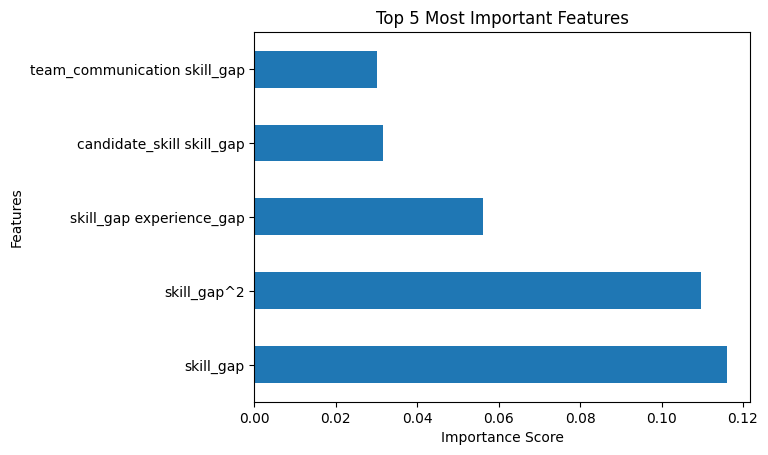

In [35]:
import matplotlib.pyplot as plt
importances = model.feature_importances_
feature_names = poly.get_feature_names_out(X.columns)
feat_importances = pd.Series(importances, index=feature_names)
# Plot top 5 features
feat_importances.nlargest(5).plot(kind='barh')
plt.title("Top 5 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()